# 1. Exploration du Dataset d'Avis d'Assurance

Ce notebook effectue une analyse exploratoire complète du dataset d'avis d'assurance.

In [3]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from pathlib import Path

In [4]:
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


## 1.1 Chargement des données

In [5]:
# Chargement des fichiers XLSX depuis le dossier 'Traduction avis clients'
import glob

DATA_DIR = Path('../data/raw/Traduction avis clients')

xlsx_files = sorted(glob.glob(str(DATA_DIR / '*.xlsx')))
if not xlsx_files:
    raise FileNotFoundError(f'Aucun fichier XLSX trouvé dans {DATA_DIR.resolve()}')

print(f'Chargement de {len(xlsx_files)} fichiers XLSX...')
dfs = []
for path in xlsx_files:
    dfs.append(pd.read_excel(path))
df = pd.concat(dfs, ignore_index=True)
print(f'Dataset fusionné : {len(df):,} lignes x {len(df.columns)} colonnes')
print(f'Colonnes : {df.columns.tolist()}')


Chargement de 35 fichiers XLSX...
Dataset fusionné : 34,435 lignes x 11 colonnes
Colonnes : ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en']


In [6]:
# Normalisation colonnes
df.columns = [c.strip().lower() for c in df.columns]

# Colonne texte : priorité à avis_en (déjà traduit en anglais)
TEXT_COL = None
for candidate in ['avis_en', 'avis_cor_en', 'review', 'review_text', 'text', 'avis']:
    if candidate in df.columns:
        TEXT_COL = candidate
        break
if TEXT_COL is None:
    obj_cols = df.select_dtypes(include='object').columns.tolist()
    TEXT_COL = obj_cols[0] if obj_cols else None

# Colonne note
RATING_COL = None
for candidate in ['note', 'stars', 'rating', 'score']:
    if candidate in df.columns:
        RATING_COL = candidate
        break

# Colonne assureur
INSURER_COL = None
for candidate in ['assureur', 'insurer', 'company', 'compagnie']:
    if candidate in df.columns:
        INSURER_COL = candidate
        break

# Colonne date
DATE_COL = None
for candidate in ['date_publication', 'date', 'created_at', 'published_at']:
    if candidate in df.columns:
        DATE_COL = candidate
        break

print(f'TEXT_COL    = {TEXT_COL}   (texte anglais traduit)')
print(f'RATING_COL  = {RATING_COL}')
print(f'INSURER_COL = {INSURER_COL}')
print(f'DATE_COL    = {DATE_COL}')

# Nettoyage notes : forcer numérique 1-5
if RATING_COL:
    df[RATING_COL] = pd.to_numeric(df[RATING_COL], errors='coerce')
    df = df.dropna(subset=[RATING_COL])
    df[RATING_COL] = df[RATING_COL].clip(1, 5).astype(int)
    print(f'\nDistribution des notes :\n{df[RATING_COL].value_counts().sort_index()}')

# Aussi disponible : 'avis' (texte original français), 'produit', 'type'
print(f'\nProduits disponibles : {df["produit"].value_counts().to_dict() if "produit" in df.columns else "N/A"}')


TEXT_COL    = avis_en   (texte anglais traduit)
RATING_COL  = note
INSURER_COL = assureur
DATE_COL    = date_publication

Distribution des notes :
note
1    7271
2    3716
3    3382
4    4885
5    4850
Name: count, dtype: int64

Produits disponibles : {'auto': 14076, 'sante': 3525, 'moto': 2105, 'habitation': 1956, 'prevoyance': 791, 'credit': 653, 'vie': 578, 'animaux': 374, 'multirisque-professionnelle': 20, 'garantie-decennale': 12, 'assurances-professionnelles': 8, 'responsabilite-civile-professionnelle': 5, 'flotte-automobile': 1}


## 1.2 Vue d'ensemble

In [7]:
print('=== Shape ===')
print(df.shape)

print('\n=== Data types ===')
print(df.dtypes)

print('\n=== First 5 rows ===')
df.head()

=== Shape ===
(24104, 11)

=== Data types ===
note                 int64
auteur              object
avis                object
assureur            object
produit             object
type                object
date_publication    object
date_exp            object
avis_en             object
avis_cor            object
avis_cor_en         object
dtype: object

=== First 5 rows ===


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,4,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,06/10/2021,01/10/2021,The person on the phone was clear and friendly...,NaN,NaN
1,4,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix att...",APRIL Moto,moto,train,09/07/2021,01/07/2021,"Satisfied.\n\nReactivity, simplicity. Attracti...",NaN,NaN
2,1,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,15/10/2020,01/10/2020,"Insurer to flee, does not ensure its responsib...",NaN,NaN
3,1,laure97134-87907,Voilà 3 mois que la GMF me fait attendre pour ...,GMF,habitation,train,03/03/2020,01/03/2020,The GMF has been waiting for a water damage fo...,NaN,NaN
4,3,bourouane-l-129916,Je suis bien avec cet assurance.elle est prati...,L'olivier Assurance,auto,train,28/08/2021,01/08/2021,I am good with this insurance. She is practica...,NaN,NaN


In [8]:
print('=== Descriptive statistics (numeric) ===')
df.describe(include='all')

=== Descriptive statistics (numeric) ===


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
count,24104.000000,24103,24104,24104,24104,24104,24104,24104,24103,0,0
unique,NaN,23675,24069,56,13,1,1801,61,23510,0,0
top,NaN,pj-97010,Intervention supprimée à la demande de l'inter...,Direct Assurance,auto,train,08/04/2021,01/09/2021,Loading...,NaN,NaN
freq,NaN,4,10,5896,14076,24104,101,1866,555,NaN,NaN
mean,2.847619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.531390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False)

print('=== Missing values ===')
if missing_df.empty:
    print('No missing values found.')
else:
    display(missing_df)

# Duplicates
n_dup = df.duplicated().sum()
print(f'\nDuplicate rows: {n_dup:,} ({n_dup/len(df)*100:.2f}%)')

=== Missing values ===


,missing_count,missing_%
avis_cor,24104,100.0
avis_cor_en,24104,100.0
auteur,1,0.0
avis_en,1,0.0



Duplicate rows: 4 (0.02%)


In [10]:
# Add review_length column if text column is available
if TEXT_COL:
    df['review_length'] = df[TEXT_COL].fillna('').apply(len)
    print(f'review_length added (based on column "{TEXT_COL}")')
    print(df['review_length'].describe())

review_length added (based on column "avis_en")
count    24104.000000
mean       313.709799
std        360.291630
min          0.000000
25%        150.000000
50%        185.000000
75%        346.000000
max       8235.000000
Name: review_length, dtype: float64


## 1.3 Distribution des étoiles

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/../figures/1_star_distribution.png'

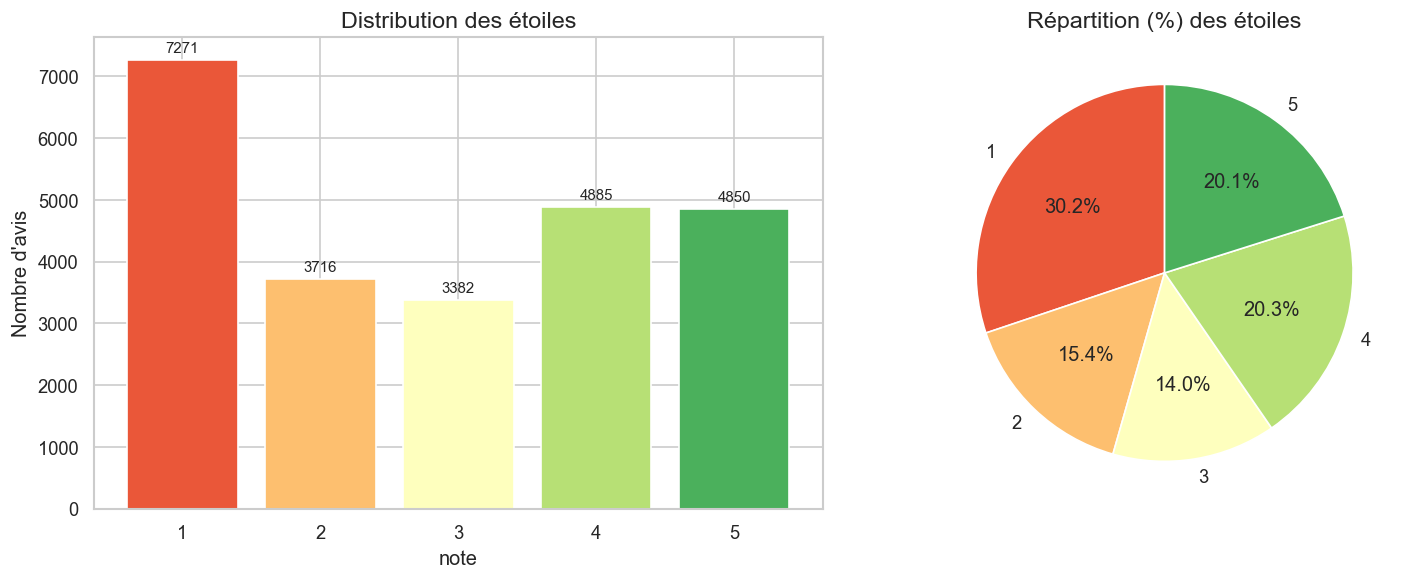

In [11]:
if RATING_COL is None:
    print(f'No rating column detected. Available columns: {df.columns.tolist()}')
else:
    rating_counts = df[RATING_COL].value_counts().sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Bar chart
    ax = axes[0]
    bars = ax.bar(rating_counts.index.astype(str), rating_counts.values,
                  color=sns.color_palette('RdYlGn', len(rating_counts)))
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
    ax.set_title('Distribution des étoiles', fontsize=14)
    ax.set_xlabel(RATING_COL)
    ax.set_ylabel('Nombre d\'avis')

    # Pie chart
    ax2 = axes[1]
    ax2.pie(rating_counts.values, labels=rating_counts.index.astype(str),
            autopct='%1.1f%%', colors=sns.color_palette('RdYlGn', len(rating_counts)),
            startangle=90)
    ax2.set_title('Répartition (%) des étoiles', fontsize=14)

    plt.tight_layout()
    plt.savefig('../data/raw/../figures/1_star_distribution.png', bbox_inches='tight', dpi=120)
    plt.show()
    print(rating_counts)

## 1.4 Longueur des reviews

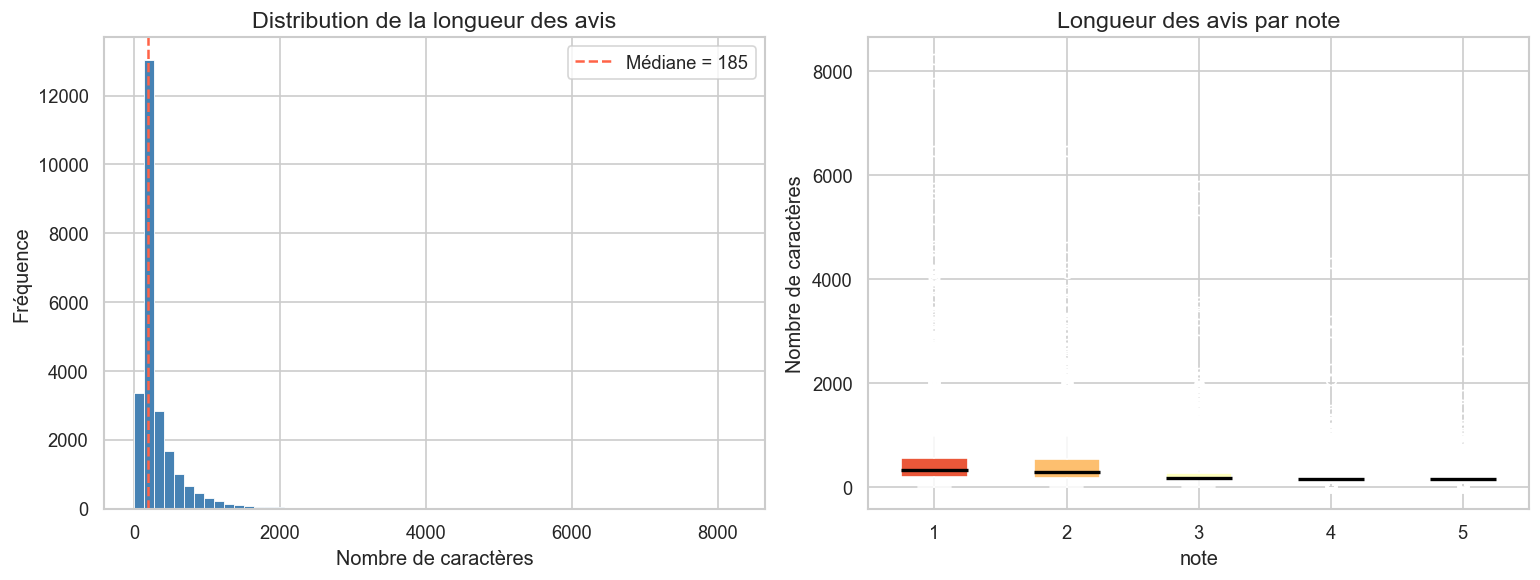

In [12]:
if 'review_length' not in df.columns:
    print('review_length column not available — skipping.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Histogram
    ax = axes[0]
    ax.hist(df['review_length'], bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title('Distribution de la longueur des avis', fontsize=14)
    ax.set_xlabel('Nombre de caractères')
    ax.set_ylabel('Fréquence')
    median_len = df['review_length'].median()
    ax.axvline(median_len, color='tomato', linestyle='--', linewidth=1.5, label=f'Médiane = {median_len:.0f}')
    ax.legend()

    # Boxplot per star rating
    ax2 = axes[1]
    if RATING_COL:
        data_by_star = [df.loc[df[RATING_COL] == s, 'review_length'].dropna().values
                        for s in sorted(df[RATING_COL].dropna().unique())]
        labels = sorted(df[RATING_COL].dropna().unique())
        bp = ax2.boxplot(data_by_star, labels=[str(l) for l in labels], patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
        colors = sns.color_palette('RdYlGn', len(labels))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        ax2.set_title('Longueur des avis par note', fontsize=14)
        ax2.set_xlabel(RATING_COL)
        ax2.set_ylabel('Nombre de caractères')
    else:
        ax2.boxplot(df['review_length'].dropna(), patch_artist=True)
        ax2.set_title('Boxplot longueur des avis', fontsize=14)

    plt.tight_layout()
    plt.show()

## 1.5 Distribution par assureur

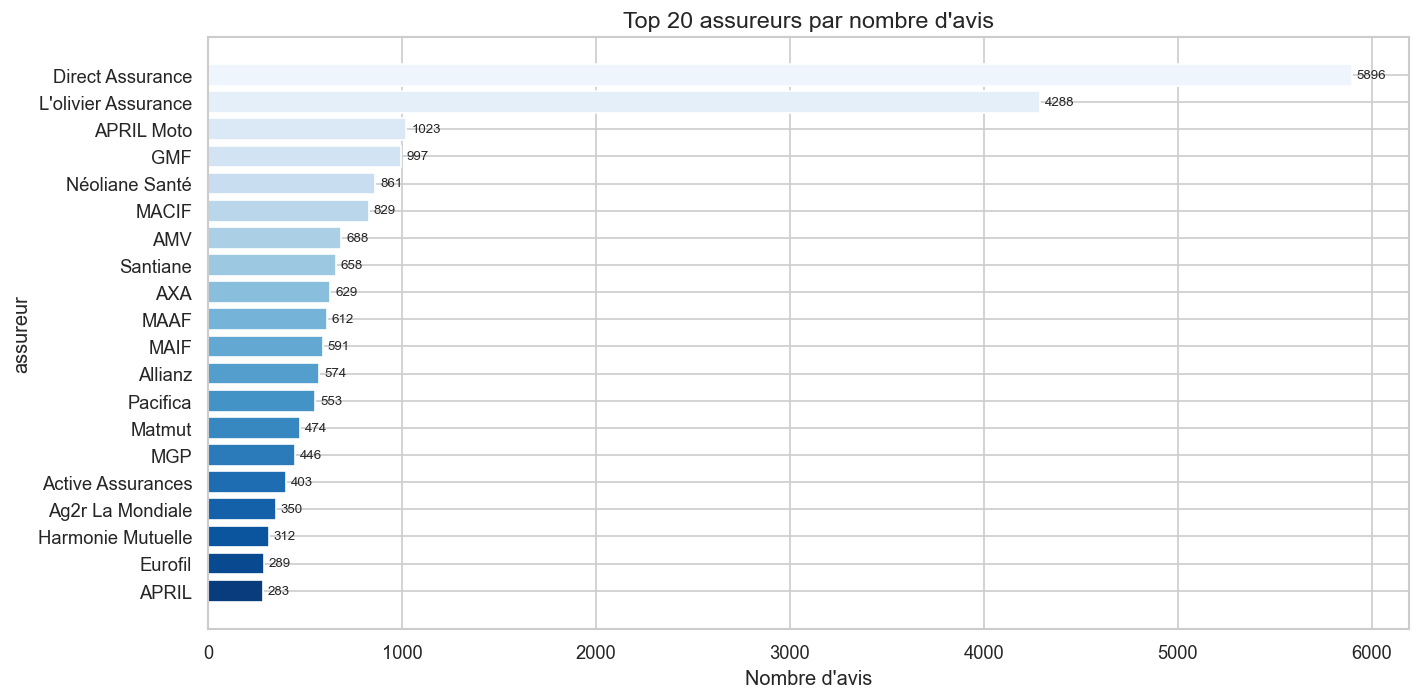


Nombre total d'assureurs uniques: 56


In [13]:
if INSURER_COL is None:
    print(f'No insurer column detected. Available columns: {df.columns.tolist()}')
else:
    top_n = 20
    insurer_counts = df[INSURER_COL].value_counts().head(top_n)

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(insurer_counts.index[::-1], insurer_counts.values[::-1],
                   color=sns.color_palette('Blues_r', top_n))
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=8)
    ax.set_title(f'Top {top_n} assureurs par nombre d\'avis', fontsize=14)
    ax.set_xlabel('Nombre d\'avis')
    ax.set_ylabel(INSURER_COL)
    plt.tight_layout()
    plt.show()

    print(f'\nNombre total d\'assureurs uniques: {df[INSURER_COL].nunique():,}')

## 1.6 WordCloud

In [14]:
if TEXT_COL is None:
    print('No text column detected — skipping WordCloud.')
else:
    try:
        from wordcloud import WordCloud

        # Basic stopwords (French + English)
        STOPWORDS = {
            'le', 'la', 'les', 'de', 'du', 'des', 'un', 'une', 'et', 'en',
            'à', 'au', 'aux', 'je', 'il', 'elle', 'nous', 'vous', 'ils', 'elles',
            'que', 'qui', 'ne', 'pas', 'plus', 'par', 'sur', 'dans', 'se', 'ce',
            'est', 'sont', 'a', 'ont', 'été', 'pour', 'avec', 'ou', 'mais', 'si',
            'mon', 'ma', 'mes', 'ton', 'ta', 'tes', 'son', 'sa', 'ses', 'leur',
            'leurs', 'y', 'me', 'te', 'lui', 'on', 'très', 'bien', 'tout',
            'the', 'a', 'an', 'is', 'in', 'it', 'of', 'to', 'and', 'i', 'my',
            'this', 'that', 'was', 'for', 'with', 'have', 'be', 'are', 'not',
        }

        all_text = ' '.join(df[TEXT_COL].fillna('').astype(str))
        # Simple cleaning
        all_text = re.sub(r'[^\w\s]', ' ', all_text.lower())

        wc = WordCloud(
            width=1200, height=600,
            background_color='white',
            max_words=200,
            stopwords=STOPWORDS,
            collocations=False,
            colormap='viridis'
        ).generate(all_text)

        fig, ax = plt.subplots(figsize=(14, 7))
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title('WordCloud des avis', fontsize=16)
        plt.tight_layout()
        plt.show()

    except ImportError:
        print('wordcloud not installed. Run: pip install wordcloud')

wordcloud not installed. Run: pip install wordcloud


## 1.7 Mots fréquents et N-grammes

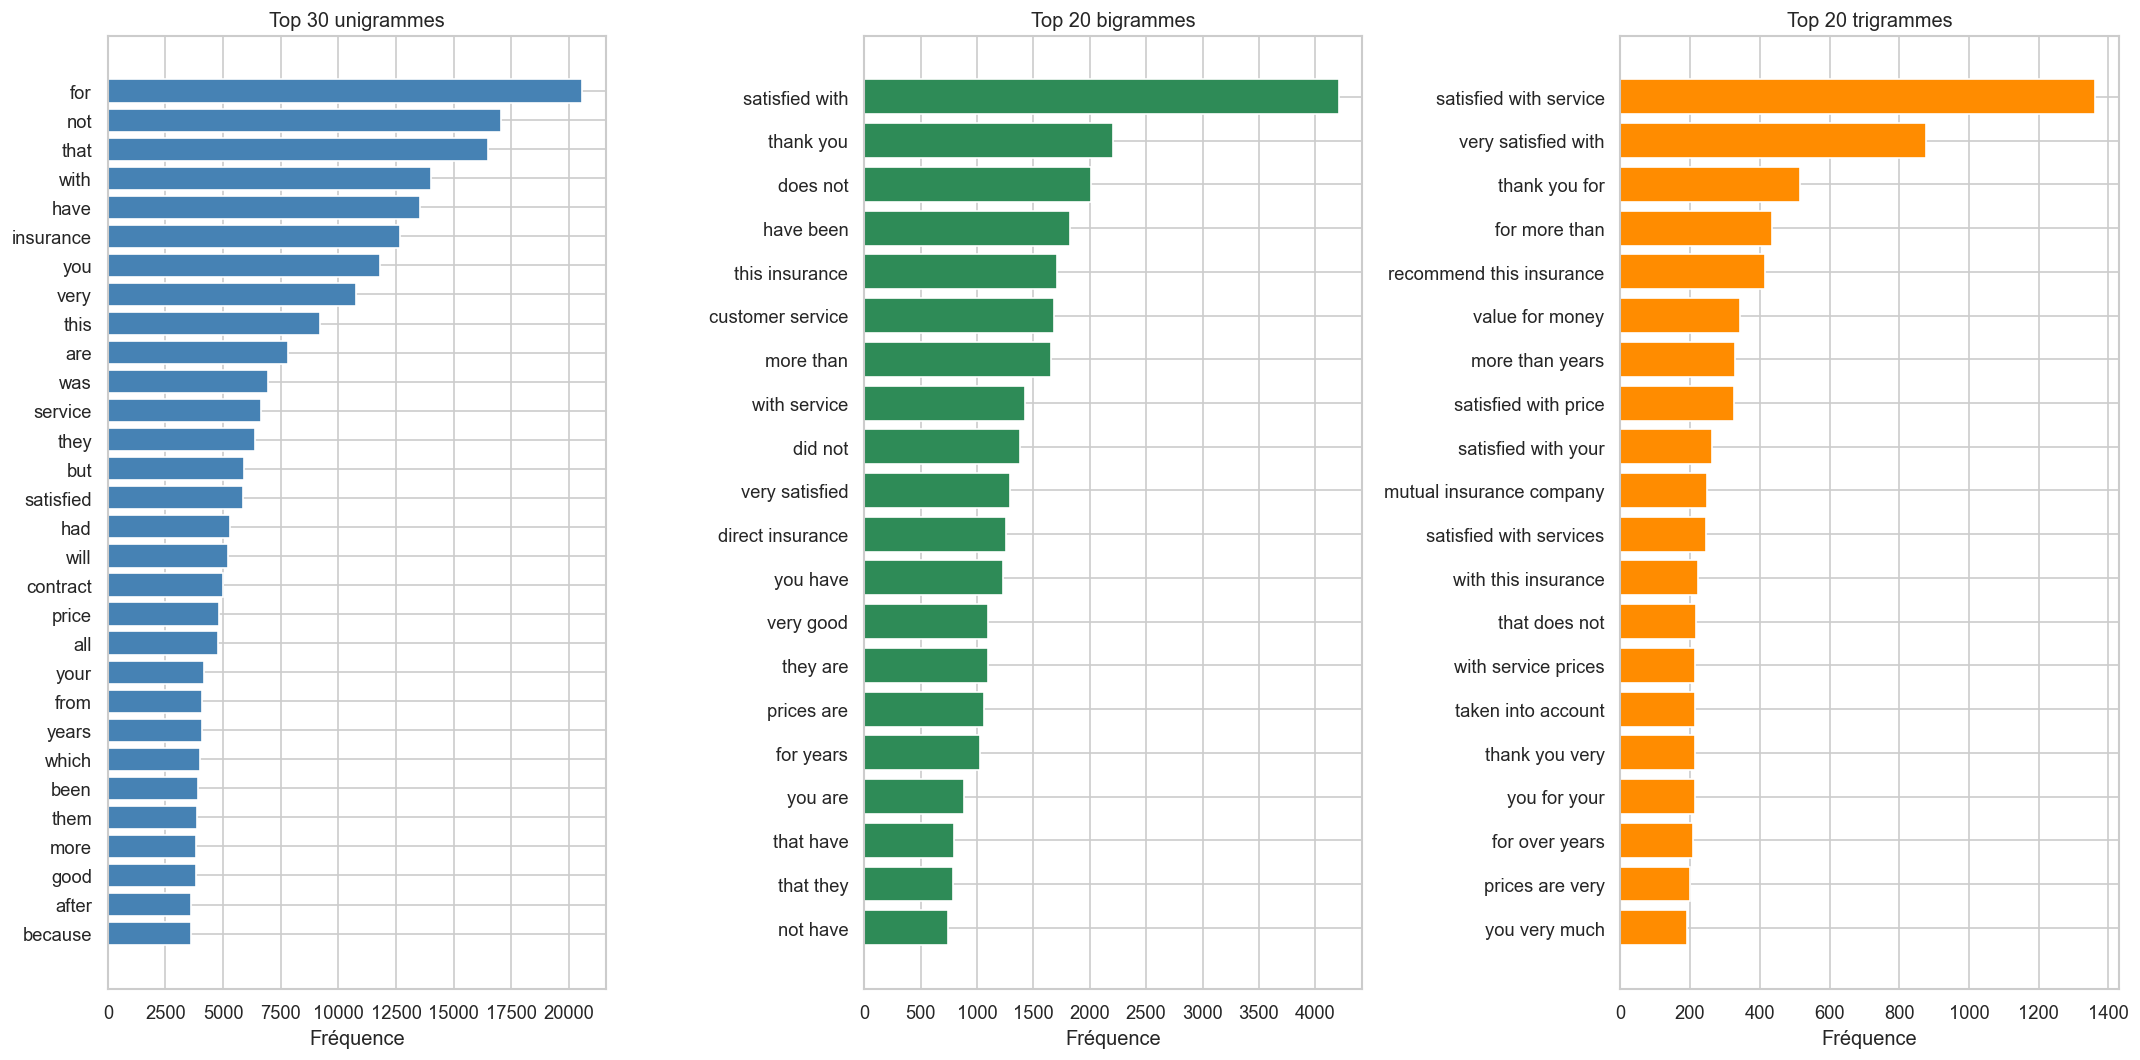

In [15]:
if TEXT_COL is None:
    print('No text column detected — skipping n-gram analysis.')
else:
    from sklearn.feature_extraction.text import CountVectorizer

    corpus = df[TEXT_COL].fillna('').astype(str).tolist()

    FRENCH_STOP = [
        'le', 'la', 'les', 'de', 'du', 'des', 'un', 'une', 'et', 'en',
        'à', 'au', 'aux', 'je', 'il', 'elle', 'nous', 'vous', 'ils', 'elles',
        'que', 'qui', 'ne', 'pas', 'plus', 'par', 'sur', 'dans', 'se', 'ce',
        'est', 'sont', 'a', 'ont', 'été', 'pour', 'avec', 'ou', 'mais', 'si',
        'mon', 'ma', 'mes', 'ton', 'ta', 'tes', 'son', 'sa', 'ses', 'leur',
        'leurs', 'y', 'me', 'te', 'lui', 'on', 'très', 'bien', 'tout', 'cette',
        'cet', 'je', 'ai', 'aussi', 'comme', 'car', 'donc', 'moi', 'toi',
        'the', 'a', 'an', 'is', 'in', 'it', 'of', 'to', 'and', 'i', 'my',
    ]

    def get_top_ngrams(corpus, ngram_range, n_top, stop_words):
        vec = CountVectorizer(ngram_range=ngram_range, stop_words=stop_words,
                              token_pattern=r'(?u)\b[a-zA-ZÀ-ÿ]{3,}\b')
        X = vec.fit_transform(corpus)
        freqs = X.sum(axis=0).A1
        vocab = vec.get_feature_names_out()
        return sorted(zip(vocab, freqs), key=lambda x: x[1], reverse=True)[:n_top]

    top_uni = get_top_ngrams(corpus, (1, 1), 30, FRENCH_STOP)
    top_bi  = get_top_ngrams(corpus, (2, 2), 20, FRENCH_STOP)
    top_tri = get_top_ngrams(corpus, (3, 3), 20, FRENCH_STOP)

    def plot_ngrams(ngrams, title, color, ax):
        words, counts = zip(*ngrams)
        bars = ax.barh(list(words)[::-1], list(counts)[::-1], color=color)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Fréquence')

    fig, axes = plt.subplots(1, 3, figsize=(18, 9))
    plot_ngrams(top_uni, 'Top 30 unigrammes', 'steelblue', axes[0])
    plot_ngrams(top_bi,  'Top 20 bigrammes',  'seagreen',  axes[1])
    plot_ngrams(top_tri, 'Top 20 trigrammes', 'darkorange', axes[2])
    plt.tight_layout()
    plt.show()

## 1.8 Détection des langues

In [16]:
if TEXT_COL is None:
    print('No text column detected — skipping language detection.')
else:
    try:
        from langdetect import detect, LangDetectException

        def safe_detect(text):
            try:
                if not isinstance(text, str) or len(text.strip()) < 10:
                    return 'unknown'
                return detect(text)
            except LangDetectException:
                return 'unknown'

        print('Detecting languages (this may take a moment)...')
        # Sample for speed if dataset is large
        sample_size = min(len(df), 5000)
        sample_idx = df.sample(n=sample_size, random_state=42).index if len(df) > sample_size else df.index

        df.loc[sample_idx, 'lang'] = df.loc[sample_idx, TEXT_COL].apply(safe_detect)

        lang_counts = df['lang'].value_counts()
        print(f'\nLanguages detected (sample of {sample_size:,} rows):')
        print(lang_counts.head(15))

        fig, ax = plt.subplots(figsize=(10, 5))
        top_langs = lang_counts.head(10)
        bars = ax.bar(top_langs.index, top_langs.values,
                      color=sns.color_palette('tab10', len(top_langs)))
        ax.bar_label(bars, fmt='%d', padding=3)
        ax.set_title('Top 10 langues détectées', fontsize=14)
        ax.set_xlabel('Langue (code ISO)')
        ax.set_ylabel('Nombre d\'avis')
        plt.tight_layout()
        plt.show()

    except ImportError:
        print('langdetect not installed. Run: pip install langdetect')

langdetect not installed. Run: pip install langdetect


## 1.9 Corrélations

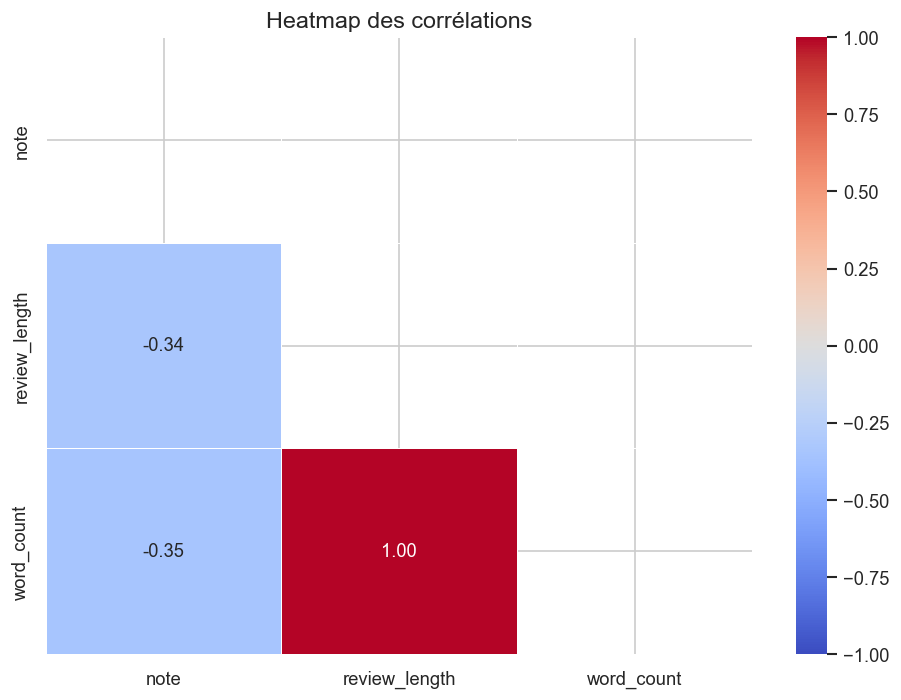


Correlation matrix:
                note  review_length  word_count
note           1.000         -0.342      -0.349
review_length -0.342          1.000       0.997
word_count    -0.349          0.997       1.000


In [17]:
# Build a numeric dataframe for correlation analysis
corr_cols = {}

if RATING_COL and pd.api.types.is_numeric_dtype(df[RATING_COL]):
    corr_cols[RATING_COL] = df[RATING_COL]
elif RATING_COL:
    corr_cols[RATING_COL] = pd.to_numeric(df[RATING_COL], errors='coerce')

if 'review_length' in df.columns:
    corr_cols['review_length'] = df['review_length']

# Word count
if TEXT_COL:
    df['word_count'] = df[TEXT_COL].fillna('').apply(lambda x: len(str(x).split()))
    corr_cols['word_count'] = df['word_count']

if len(corr_cols) < 2:
    print('Not enough numeric columns for a correlation heatmap.')
else:
    corr_df = pd.DataFrame(corr_cols)
    corr_matrix = corr_df.corr()

    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                mask=mask, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
                annot_kws={'size': 11})
    ax.set_title('Heatmap des corrélations', fontsize=14)
    plt.tight_layout()
    plt.show()

    print('\nCorrelation matrix:')
    print(corr_matrix.round(3))

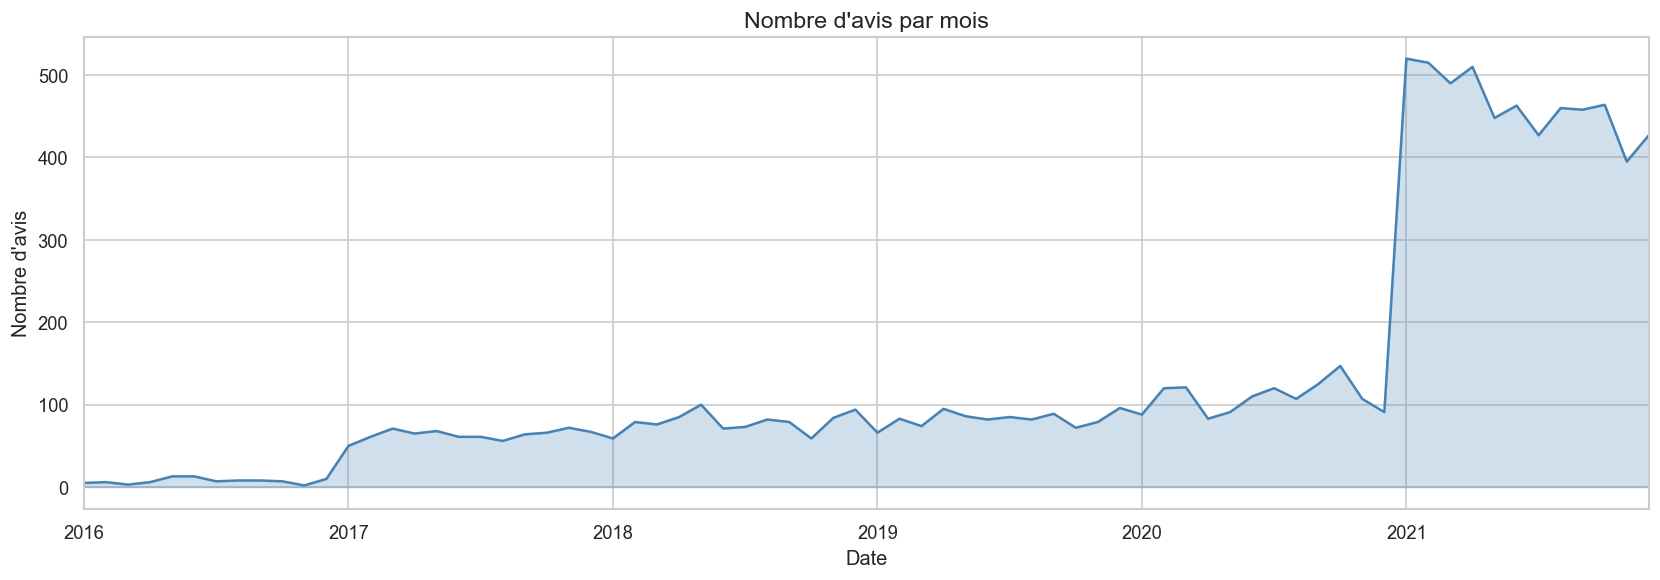

Date range: 2016-01-12 00:00:00 → 2021-12-11 00:00:00
Total months with data: 72


In [18]:
# Timeline of reviews (only if a date column was found)
if DATE_COL is None:
    print('No date column detected — skipping timeline.')
else:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
    n_invalid = df[DATE_COL].isna().sum()
    if n_invalid > 0:
        print(f'Warning: {n_invalid:,} rows with unparseable dates were dropped from the timeline.')

    timeline = df.dropna(subset=[DATE_COL]).set_index(DATE_COL).resample('ME').size()

    fig, ax = plt.subplots(figsize=(14, 5))
    timeline.plot(ax=ax, color='steelblue', linewidth=1.5)
    ax.fill_between(timeline.index, timeline.values, alpha=0.25, color='steelblue')
    ax.set_title('Nombre d\'avis par mois', fontsize=14)
    ax.set_xlabel('Date')
    ax.set_ylabel('Nombre d\'avis')
    plt.tight_layout()
    plt.show()

    print(f'Date range: {df[DATE_COL].min()} → {df[DATE_COL].max()}')
    print(f'Total months with data: {len(timeline)}')

---

**Fin de l'exploration.** Les sections suivantes du projet s'appuieront sur ces observations pour le prétraitement, la modélisation et l'évaluation.